In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import modified_rf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
from modified_rf import RandomForestRegressor621
from importlib import reload

reload(modified_rf)

np.random.seed(24)

In [13]:
X = np.loadtxt("TMB Featurespace Trimmed.csv", delimiter = ',')
y = np.loadtxt("TMB Outputs Trimmed.csv")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [34]:
def forest(label_depth, n_estimators):
    rf1 = RandomForestRegressor621(n_estimators=n_estimators, min_samples_leaf=5, max_features=0.4, max_depth=None, label_depth=label_depth, force_label_split=False, oob_score=False)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\nLinear Test Accuracy:",accuracy_score)
    
    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)

    #calculate accuracy for each dataset in Xtest
    unique_vals = np.unique(X[:, -1])  # get unique values in last column
    sourced_X_test = []
    sourced_train_score = []
    for val in unique_vals:
        sourced_test = X_test[X_test[:, -1] == val]
        sourced_key = y_test[X_test[:, -1] == val]
        sourced_X_test.append(sourced_test)
        sourced_train_score.append(rf1.score(sourced_test, sourced_key))


    return train_score, accuracy_score, rf1, sourced_train_score

In [35]:
'''Forest Training block'''
train_score = []
accuracy_score = []
rf1 = []
sourced_accuracy_scores=[]

for i in range(10):
    print("forest", i)
    temp_train_score, temp_accuracy_score, temp_rf1, sourced_accuracy_score = forest(i, 500)
    train_score.append(temp_train_score)
    accuracy_score.append(temp_accuracy_score)
    rf1.append(temp_rf1)
    sourced_accuracy_scores.append(sourced_accuracy_score)

sourced_accuracy_scores = np.array(sourced_accuracy_scores)

forest 0
Tree: 499
Linear Test Accuracy: 0.32715187118332867

 Training Accuracy: 0.7974105165069405
forest 1
Tree: 499
Linear Test Accuracy: 0.3275192413687128

 Training Accuracy: 0.7991691777299614
forest 2
Tree: 499
Linear Test Accuracy: 0.3238800766973301

 Training Accuracy: 0.7962800982844285
forest 3
Tree: 499
Linear Test Accuracy: 0.3122545196415586

 Training Accuracy: 0.7800384782930824
forest 4
Tree: 499
Linear Test Accuracy: 0.30191238609802007

 Training Accuracy: 0.7805973871306842
forest 5
Tree: 499
Linear Test Accuracy: 0.2923803234728173

 Training Accuracy: 0.7801404859446012
forest 6
Tree: 499
Linear Test Accuracy: 0.2801276199299021

 Training Accuracy: 0.7772961006403053
forest 7
Tree: 499
Linear Test Accuracy: 0.27946752625976135

 Training Accuracy: 0.7773550638246304
forest 8
Tree: 499
Linear Test Accuracy: 0.2826075716509917

 Training Accuracy: 0.7773509190381425
forest 9
Tree: 499
Linear Test Accuracy: 0.2712372251905013

 Training Accuracy: 0.77613331712772

[384, 253, 314, 406, 209, 223, 270]


Text(0.5, 1.0, 'Sourced accuracy on Lasso trimmed Data by D0 depth')

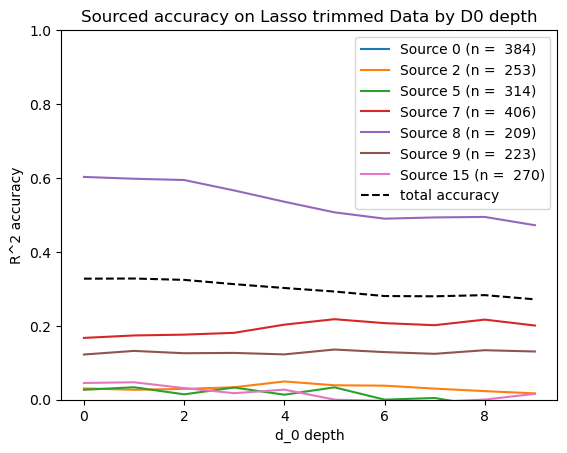

In [53]:
'''
Sourced Accuracy
'''
source_sizes = []
unique_vals = np.unique(X[:, -1])  # get unique values in last column
for val in unique_vals:
    source_sizes.append(len(X_train[X_train[:, -1] == val]))

print(source_sizes)

depth = np.arange(10)
for i in range(7):
    plt.plot(depth, sourced_accuracy_scores[:,i], label = f"Source {int(unique_vals[i])} (n =  {source_sizes[i]})")
plt.plot(depth, accuracy_score, color = 'black', linestyle = "dashed", label = "total accuracy")
plt.xlabel('d_0 depth')
plt.ylabel('R^2 accuracy')
plt.legend()
plt.ylim(0,1)
plt.title("Sourced accuracy on Lasso trimmed Data by D0 depth")

0.0
2.0
5.0
7.0
8.0
9.0
15.0


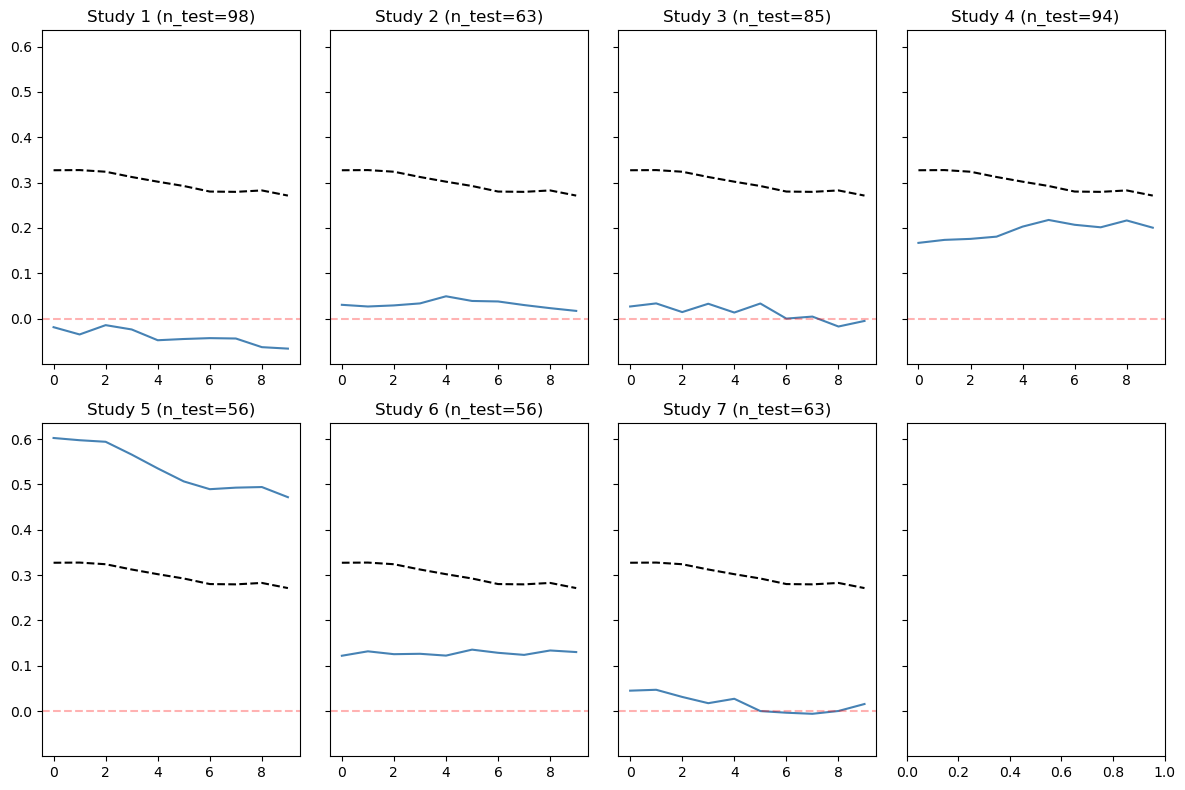

In [50]:
fig, axes = plt.subplots(2, 4, figsize=(12,8), sharey=True)
axes = axes.flatten()

for idx, study in enumerate(unique_vals):
    print(study)
    axes[idx].plot(depth, sourced_accuracy_scores[:,idx], color='steelblue')
    axes[idx].plot(depth, accuracy_score, 'k--', label='total')
    axes[idx].axhline(0, color='r', linestyle='--', alpha=0.3)
    axes[idx].set_title(f'Study {idx+1} (n_test={source_sizes[idx]})')
    #axes[idx].set_ylim(0, 0.6)

plt.tight_layout()

In [ ]:
'''
Histogram of First Split by label depth by trees
'''

flsd = [] #first label split depth
for i in range(8):
    flsd_temp = np.zeros(len(rf1[i].trees))
    for j in range(len(rf1[i].trees)):
        flsd_temp[j] = rf1[i].trees[j][0].first_label_split_depth
    flsd.append(flsd_temp)

plt.hist(flsd[0:4], stacked=False, bins = 16, label = ['Label Depth = 1', 'Label Depth = 2', 'Label Depth = 3', 'Label Depth = 4'])
plt.ylabel('Trees')
plt.xlabel('First label split')
plt.title('Distribution of First Label Split Depths')
plt.legend()